In [8]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
X = np.array([
    [500, 1, 5],
    [750, 2, 3],
    [1000, 2, 8],
    [1200, 3, 2],
    [1500, 3, 10],
    [1800, 4, 1],
    [2000, 4, 6]
])

rent = np.array([15, 22, 25, 35, 38, 50, 52])

In [4]:
single_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
single_tree.fit(X, rent)

pred_single = single_tree.predict(X)
mse_single = mean_squared_error(rent, pred_single)
print("Single Tree MSE:", mse_single)

Single Tree MSE: 0.0


In [5]:
forest = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
forest.fit(X, rent)

pred_forest = forest.predict(X)
mse_forest = mean_squared_error(rent, pred_forest)
print("Random Forest MSE:", mse_forest)

Random Forest MSE: 2.62845


In [6]:
new_house = [[1300, 3, 4]]

pred_single_new = single_tree.predict(new_house)
pred_forest_new = forest.predict(new_house)

print("Single Tree Prediction:", pred_single_new[0])
print("Random Forest Prediction:", pred_forest_new[0])

Single Tree Prediction: 35.0
Random Forest Prediction: 35.61


In [9]:
boosting_model = GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.1, random_state=42)
boosting_model.fit(X, rent)

pred_boosting = boosting_model.predict(X)
mse_boosting = mean_squared_error(rent, pred_boosting)
print("Boosting MSE:", mse_boosting)

Boosting MSE: 4.4921009109011086e-07


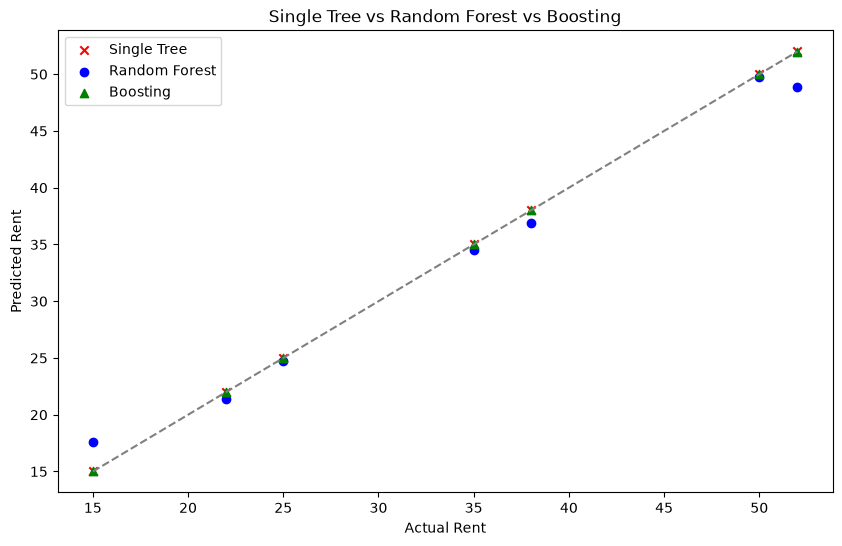

In [10]:
plt.figure(figsize=(10,6))
plt.scatter(rent, pred_single, color='red', label='Single Tree', marker='x')
plt.scatter(rent, pred_forest, color='blue', label='Random Forest', marker='o')
plt.scatter(rent, pred_boosting, color='green', label='Boosting', marker='^')
plt.plot([min(rent), max(rent)], [min(rent), max(rent)], color='gray', linestyle='--')
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.legend()
plt.title("Single Tree vs Random Forest vs Boosting")
plt.show()